In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving perf_results.csv to perf_results.csv


In [ ]:
csv_perfres_img = "perf_results.csv"
df = pd.read_csv(csv_perfres_img)

df.head()

,image,condition,coldLoad,webgl,model_load_ms,apply_model_ms,post_ms,total_ms
0,cat108.jpg,full_pipeline,True,True,17087,23296,165,73560
1,cityG.jpg,full_pipeline,True,True,5066,1901,191,11232
2,drinksW.jpg,full_pipeline,False,True,0,1747,114,6558
3,FitnessW.jpg,full_pipeline,False,True,0,462,93,3432
4,fitnessW1.jpg,full_pipeline,False,True,0,1383,144,4321


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nPreview:")
display(df.head())

Columns:
['image', 'condition', 'coldLoad', 'webgl', 'model_load_ms', 'apply_model_ms', 'post_ms', 'total_ms']

Shape:
(38, 8)

Preview:


,image,condition,coldLoad,webgl,model_load_ms,apply_model_ms,post_ms,total_ms
0,cat108.jpg,full_pipeline,True,True,17087,23296,165,73560
1,cityG.jpg,full_pipeline,True,True,5066,1901,191,11232
2,drinksW.jpg,full_pipeline,False,True,0,1747,114,6558
3,FitnessW.jpg,full_pipeline,False,True,0,462,93,3432
4,fitnessW1.jpg,full_pipeline,False,True,0,1383,144,4321


In [ ]:
numeric_cols = ["model_load_ms", "apply_model_ms", "post_ms", "total_ms"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["coldLoad"] = df["coldLoad"].astype(str).str.lower().map({
    "true": True,
    "false": False
})

df["webgl"] = df["webgl"].astype(str).str.lower().map({
    "true": True,
    "false": False
})

print(df.dtypes)

image             object
condition         object
coldLoad            bool
webgl               bool
model_load_ms      int64
apply_model_ms     int64
post_ms            int64
total_ms           int64
dtype: object


In [ ]:
cold_df = df[df["coldLoad"] == True].copy()
warm_df = df[df["coldLoad"] == False].copy()

print("Total runs:", len(df))
print("Cold runs:", len(cold_df))
print("Warm runs:", len(warm_df))

Total runs: 38
Cold runs: 3
Warm runs: 35


In [ ]:
metrics = ["model_load_ms", "apply_model_ms", "post_ms", "total_ms"]

overall_summary = df[metrics].agg(["mean", "median", "std", "min", "max"]).T
cold_summary = cold_df[metrics].agg(["mean", "median", "std", "min", "max"]).T
warm_summary = warm_df[metrics].agg(["mean", "median", "std", "min", "max"]).T

print("Overall summary")
display(overall_summary)

print("Cold-load summary")
display(cold_summary)

print("Warm-load summary")
display(warm_summary)

Overall summary


,mean,median,std,min,max
model_load_ms,649.631579,0.0,2885.233649,0.0,17087.0
apply_model_ms,2128.026316,1454.5,3570.863220,462.0,23296.0
post_ms,128.526316,98.0,84.531375,78.0,494.0
total_ms,6689.894737,4515.5,11244.320911,3108.0,73560.0


Cold-load summary


,mean,median,std,min,max
model_load_ms,8228.666667,5066.0,7775.382584,2533.0,17087.0
apply_model_ms,8929.333333,1901.0,12442.863751,1591.0,23296.0
post_ms,171.000000,165.0,17.776389,157.0,191.0
total_ms,30488.333333,11232.0,37370.743535,6673.0,73560.0


Warm-load summary


,mean,median,std,min,max
model_load_ms,0.000000,0.0,0.000000,0.0,0.0
apply_model_ms,1545.057143,1383.0,580.858084,462.0,2741.0
post_ms,124.885714,97.0,87.089802,78.0,494.0
total_ms,4650.028571,4440.0,1087.454921,3108.0,7444.0


In [ ]:
comparison_table = pd.DataFrame({
    "cold_mean_ms": cold_df[metrics].mean(),
    "cold_median_ms": cold_df[metrics].median(),
    "cold_std_ms": cold_df[metrics].std(),
    "warm_mean_ms": warm_df[metrics].mean(),
    "warm_median_ms": warm_df[metrics].median(),
    "warm_std_ms": warm_df[metrics].std()
}).round(2)

comparison_table

,cold_mean_ms,cold_median_ms,cold_std_ms,warm_mean_ms,warm_median_ms,warm_std_ms
model_load_ms,8228.67,5066.0,7775.38,0.00,0.0,0.00
apply_model_ms,8929.33,1901.0,12442.86,1545.06,1383.0,580.86
post_ms,171.00,165.0,17.78,124.89,97.0,87.09
total_ms,30488.33,11232.0,37370.74,4650.03,4440.0,1087.45


In [ ]:
comparison_table.to_csv("cold_vs_warm_comparison.csv")
overall_summary.to_csv("overall_summary.csv")
cold_summary.to_csv("cold_summary.csv")
warm_summary.to_csv("warm_summary.csv")

In [ ]:
recap_table = pd.DataFrame([
    {
        "Run type": "Cold-load",
        "Number of runs": len(cold_df),
        "Model load mean (ms)": round(cold_df["model_load_ms"].mean(), 2),
        "Apply model mean (ms)": round(cold_df["apply_model_ms"].mean(), 2),
        "Post mean (ms)": round(cold_df["post_ms"].mean(), 2),
        "Total mean (ms)": round(cold_df["total_ms"].mean(), 2)
    },
    {
        "Run type": "Warm-load",
        "Number of runs": len(warm_df),
        "Model load mean (ms)": round(warm_df["model_load_ms"].mean(), 2),
        "Apply model mean (ms)": round(warm_df["apply_model_ms"].mean(), 2),
        "Post mean (ms)": round(warm_df["post_ms"].mean(), 2),
        "Total mean (ms)": round(warm_df["total_ms"].mean(), 2)
    }
])

recap_table

,Run type,Number of runs,Model load mean (ms),Apply model mean (ms),Post mean (ms),Total mean (ms)
0,Cold-load,3,8228.67,8929.33,171.00,30488.33
1,Warm-load,35,0.00,1545.06,124.89,4650.03


In [ ]:
recap_table.to_csv("recap_table.csv", index=False)

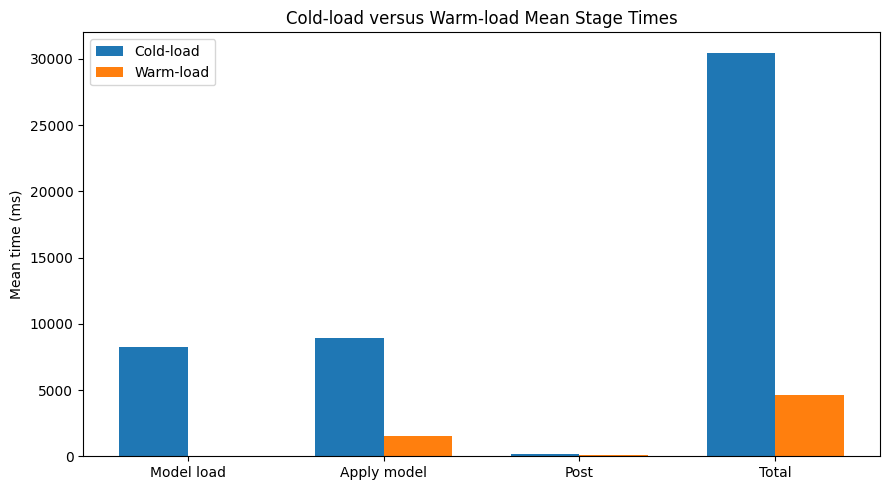

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

stage_names = ["model_load_ms", "apply_model_ms", "post_ms", "total_ms"]
cold_means = [cold_df[col].mean() for col in stage_names]
warm_means = [warm_df[col].mean() for col in stage_names]

x = np.arange(len(stage_names))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, cold_means, width, label="Cold-load")
plt.bar(x + width/2, warm_means, width, label="Warm-load")

plt.xticks(x, ["Model load", "Apply model", "Post", "Total"])
plt.ylabel("Mean time (ms)")
plt.title("Cold-load versus Warm-load Mean Stage Times")
plt.legend()
plt.tight_layout()
plt.show()

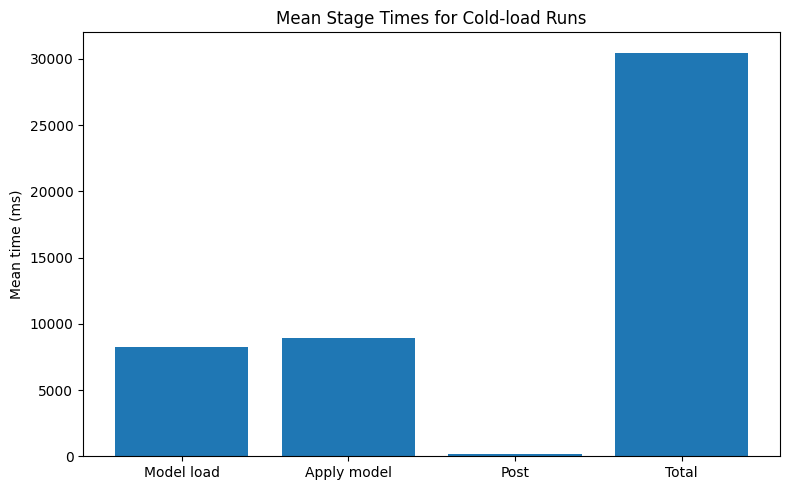

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    ["Model load", "Apply model", "Post", "Total"],
    [cold_df["model_load_ms"].mean(),
     cold_df["apply_model_ms"].mean(),
     cold_df["post_ms"].mean(),
     cold_df["total_ms"].mean()]
)
plt.ylabel("Mean time (ms)")
plt.title("Mean Stage Times for Cold-load Runs")
plt.tight_layout()
plt.show()

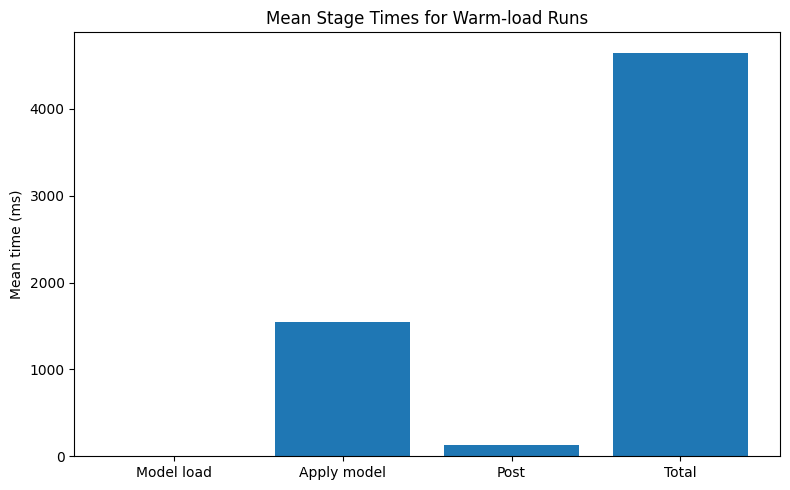

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    ["Model load", "Apply model", "Post", "Total"],
    [warm_df["model_load_ms"].mean(),
     warm_df["apply_model_ms"].mean(),
     warm_df["post_ms"].mean(),
     warm_df["total_ms"].mean()]
)
plt.ylabel("Mean time (ms)")
plt.title("Mean Stage Times for Warm-load Runs")
plt.tight_layout()
plt.show()

/tmp/ipykernel_23747/193638872.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


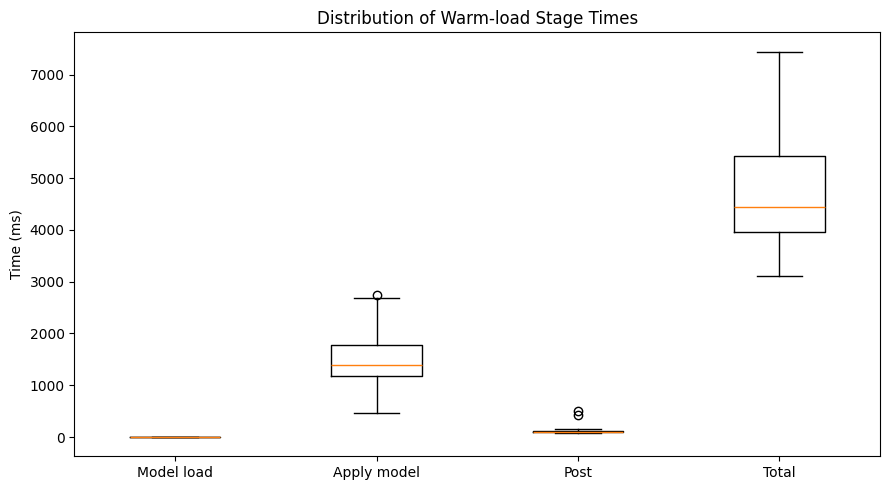

In [ ]:
plt.figure(figsize=(9, 5))
plt.boxplot([
    warm_df["model_load_ms"].dropna(),
    warm_df["apply_model_ms"].dropna(),
    warm_df["post_ms"].dropna(),
    warm_df["total_ms"].dropna()
], labels=["Model load", "Apply model", "Post", "Total"])
plt.ylabel("Time (ms)")
plt.title("Distribution of Warm-load Stage Times")
plt.tight_layout()
plt.show()

/tmp/ipykernel_23747/1066959176.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


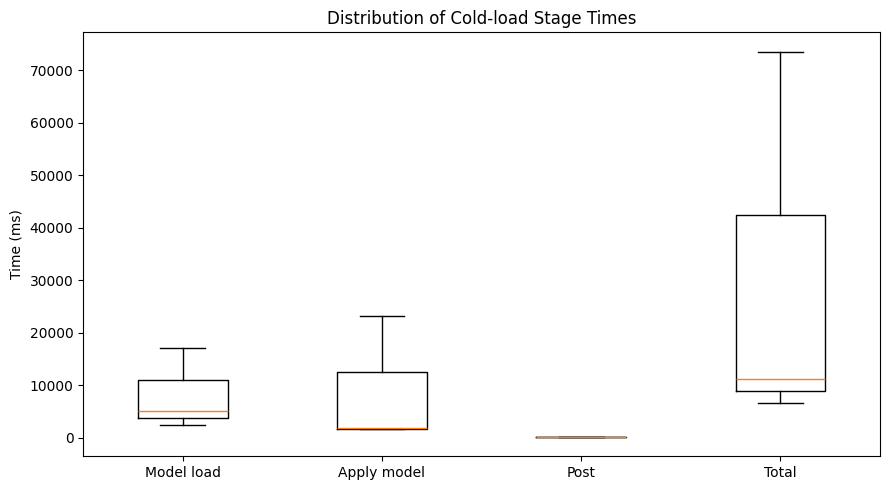

In [ ]:
plt.figure(figsize=(9, 5))
plt.boxplot([
    cold_df["model_load_ms"].dropna(),
    cold_df["apply_model_ms"].dropna(),
    cold_df["post_ms"].dropna(),
    cold_df["total_ms"].dropna()
], labels=["Model load", "Apply model", "Post", "Total"])
plt.ylabel("Time (ms)")
plt.title("Distribution of Cold-load Stage Times")
plt.tight_layout()
plt.show()

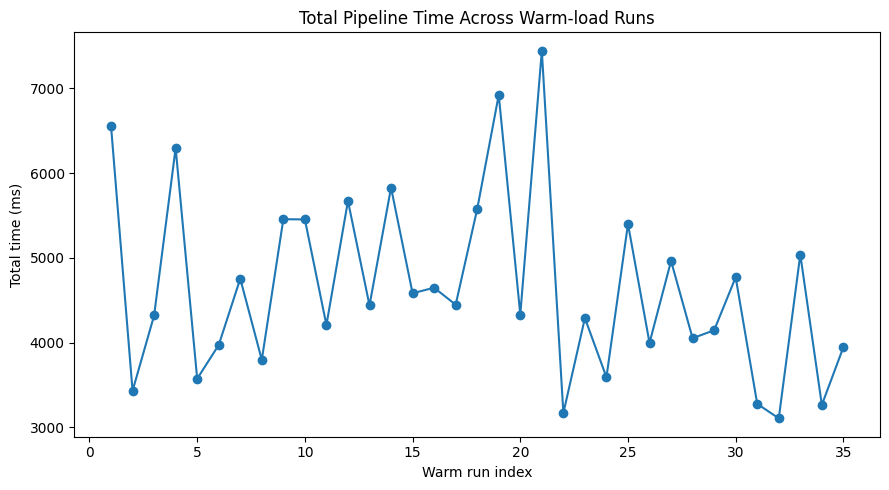

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(warm_df) + 1), warm_df["total_ms"].values, marker="o")
plt.xlabel("Warm run index")
plt.ylabel("Total time (ms)")
plt.title("Total Pipeline Time Across Warm-load Runs")
plt.tight_layout()
plt.show()

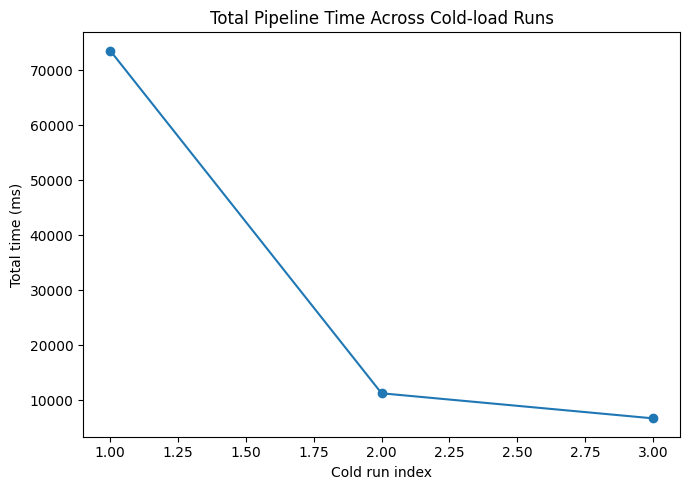

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cold_df) + 1), cold_df["total_ms"].values, marker="o")
plt.xlabel("Cold run index")
plt.ylabel("Total time (ms)")
plt.title("Total Pipeline Time Across Cold-load Runs")
plt.tight_layout()
plt.show()

In [ ]:
seconds_comparison = comparison_table / 1000
seconds_comparison.round(2)

,cold_mean_ms,cold_median_ms,cold_std_ms,warm_mean_ms,warm_median_ms,warm_std_ms
model_load_ms,8.23,5.07,7.78,0.00,0.00,0.00
apply_model_ms,8.93,1.90,12.44,1.55,1.38,0.58
post_ms,0.17,0.16,0.02,0.12,0.10,0.09
total_ms,30.49,11.23,37.37,4.65,4.44,1.09


In [ ]:
recap_table_seconds = recap_table.copy()

for col in recap_table_seconds.columns:
    if "(ms)" in col:
        recap_table_seconds[col.replace("(ms)", "(s)")] = (recap_table_seconds[col] / 1000).round(2)

recap_table_seconds

,Run type,Number of runs,Model load mean (ms),Apply model mean (ms),Post mean (ms),Total mean (ms),Model load mean (s),Apply model mean (s),Post mean (s),Total mean (s)
0,Cold-load,3,8228.67,8929.33,171.00,30488.33,8.23,8.93,0.17,30.49
1,Warm-load,35,0.00,1545.06,124.89,4650.03,0.00,1.55,0.12,4.65
